# Phase 6 — Sentiment Classification

Predict:
`Positive / Negative / Neutral`

Input:
`clean_text`

Target:
`rating_review`

Models:
1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM

Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Macro F1
- Confusion matrix

Because the dataset is imbalanced, macro F1 and per-class metrics are important.


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

print("Phase 6 imports loaded.")


Phase 6 imports loaded.


## 1. Load data

In [2]:
df = pd.read_csv("../data/processed/yelp_reviews_nlp.csv")

X = df["clean_text"].fillna("")
y = df["rating_review"]

print("Shape:", df.shape)
print(y.value_counts())


Shape: (14351, 12)
rating_review
Positive    9857
Negative    2699
Neutral     1795
Name: count, dtype: int64


## 2. Train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test :", len(X_test))


Train: 11480
Test : 2871


## 3. TF-IDF vectorization

In [4]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature matrix:", X_train_tfidf.shape)
print("Testing feature matrix :", X_test_tfidf.shape)


Training feature matrix: (11480, 20000)
Testing feature matrix : (2871, 20000)


## 4. Logistic Regression

In [5]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)
logistic_pred = logistic_model.predict(X_test_tfidf)

print(classification_report(y_test, logistic_pred))
print("Macro F1:", round(f1_score(y_test, logistic_pred, average="macro"), 4))


              precision    recall  f1-score   support

    Negative       0.79      0.80      0.79       540
     Neutral       0.39      0.49      0.43       359
    Positive       0.93      0.88      0.90      1972

    accuracy                           0.81      2871
   macro avg       0.70      0.72      0.71      2871
weighted avg       0.83      0.81      0.82      2871

Macro F1: 0.7087


## 5. Multinomial Naive Bayes

In [6]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

print(classification_report(y_test, nb_pred))
print("Macro F1:", round(f1_score(y_test, nb_pred, average="macro"), 4))


              precision    recall  f1-score   support

    Negative       0.94      0.42      0.58       540
     Neutral       0.00      0.00      0.00       359
    Positive       0.75      1.00      0.86      1972

    accuracy                           0.76      2871
   macro avg       0.56      0.47      0.48      2871
weighted avg       0.69      0.76      0.70      2871

Macro F1: 0.4775


c:\Users\mahad\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\mahad\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\mahad\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## 6. Linear SVM

In [7]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

print(classification_report(y_test, svm_pred))
print("Macro F1:", round(f1_score(y_test, svm_pred, average="macro"), 4))


              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80       540
     Neutral       0.41      0.31      0.35       359
    Positive       0.90      0.94      0.92      1972

    accuracy                           0.83      2871
   macro avg       0.70      0.68      0.69      2871
weighted avg       0.82      0.83      0.82      2871

Macro F1: 0.6888


## 7. Compare models

In [8]:
models = {
    "Logistic Regression": logistic_pred,
    "Multinomial Naive Bayes": nb_pred,
    "Linear SVM": svm_pred
}

results = []

for name, predictions in models.items():
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, predictions,
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

results_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.814350,0.700101,0.721751,0.708748
1,Linear SVM,0.832463,0.702952,0.679694,0.688790
2,Multinomial Naive Bayes,0.764194,0.561962,0.471715,0.477484


## 8. Confusion matrix — Logistic Regression

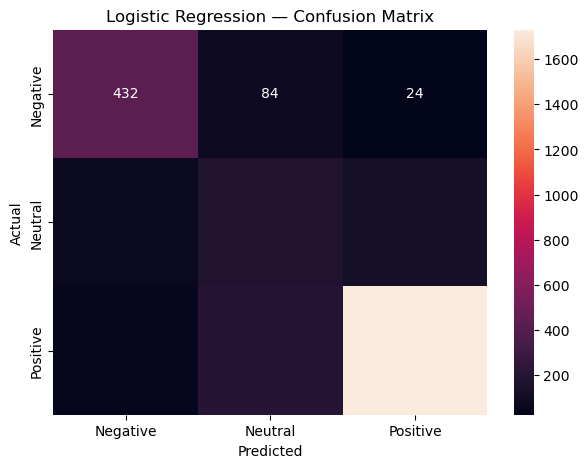

In [9]:
cm = confusion_matrix(
    y_test,
    logistic_pred,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 9. Save the deployment model

In [10]:
model_dir = "../model"
os.makedirs(model_dir, exist_ok=True)

# Logistic Regression supports predict_proba(), which is useful for
# the confidence value shown later in the Flutter app.
joblib.dump(logistic_model, os.path.join(model_dir, "sentiment_model.joblib"))
joblib.dump(vectorizer, os.path.join(model_dir, "tfidf_vectorizer.joblib"))

print("Saved:")
print("-", os.path.join(model_dir, "sentiment_model.joblib"))
print("-", os.path.join(model_dir, "tfidf_vectorizer.joblib"))


Saved:
- ../model\sentiment_model.joblib
- ../model\tfidf_vectorizer.joblib


## 10. Test a custom review

In [11]:
def predict_review(review):
    review_vector = vectorizer.transform([review])
    prediction = logistic_model.predict(review_vector)[0]
    probabilities = logistic_model.predict_proba(review_vector)[0]

    confidence = float(np.max(probabilities))
    probability_map = dict(zip(logistic_model.classes_, probabilities))

    return prediction, confidence, probability_map

test_review = "The food was delicious and the service was excellent."

prediction, confidence, probability_map = predict_review(test_review)

print("Review:", test_review)
print("Prediction:", prediction)
print("Confidence:", round(confidence, 4))
print("Probabilities:", probability_map)


Review: The food was delicious and the service was excellent.
Prediction: Positive
Confidence: 0.994
Probabilities: {'Negative': 0.0003523088998413753, 'Neutral': 0.0056818256111240886, 'Positive': 0.9939658654890347}


## Phase 6 conclusion

Saved artifacts:
- `model/sentiment_model.joblib`
- `model/tfidf_vectorizer.joblib`

These artifacts will later be loaded by FastAPI.
